# Clustering — K-Means
Identifica grupos de trabalhadores com perfis similares de vulnerabilidade à IA.

In [1]:
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, davies_bouldin_score

plt.rcParams['figure.figsize'] = (10, 5)
sns.set_theme(style='whitegrid')

# Carregar dados pré-processados
X_scaled = np.load('../dataset/X_scaled.npy')

with open('../dataset/preprocessamento.pkl', 'rb') as f:
    meta = pickle.load(f)

df_orig = meta['df_original']
print(f'Matriz carregada: {X_scaled.shape}')

Matriz carregada: (2000, 42)


## 1. Elbow Method — escolha do K
Plota a inércia (soma das distâncias intra-cluster) para diferentes valores de K.

In [2]:
K_RANGE = range(2, 11)

inercias = []
silhouettes = []

for k in K_RANGE:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inercias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels))
    print(f'K={k:2d} | Inércia={km.inertia_:,.0f} | Silhouette={silhouettes[-1]:.4f}')

K= 2 | Inércia=79,536 | Silhouette=0.0549
K= 3 | Inércia=75,079 | Silhouette=0.0868
K= 4 | Inércia=70,633 | Silhouette=0.1173
K= 5 | Inércia=66,191 | Silhouette=0.1461
K= 6 | Inércia=61,758 | Silhouette=0.1755
K= 7 | Inércia=57,318 | Silhouette=0.2059
K= 8 | Inércia=55,198 | Silhouette=0.2109
K= 9 | Inércia=53,056 | Silhouette=0.2138
K=10 | Inércia=50,932 | Silhouette=0.2203


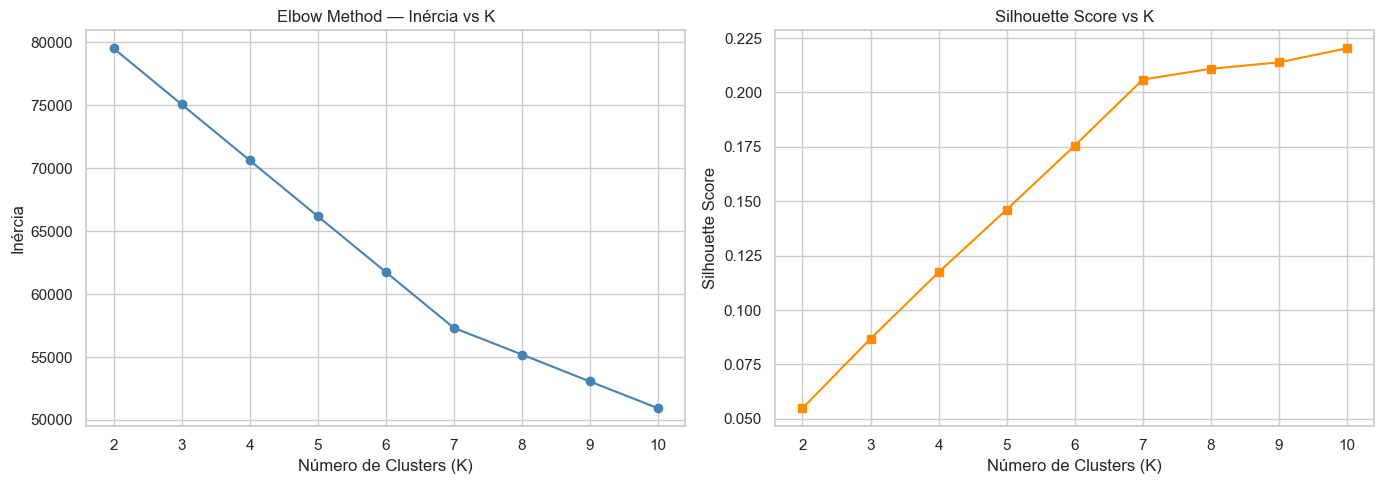


Melhor K pelo Silhouette: 10


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(K_RANGE, inercias, 'o-', color='steelblue')
axes[0].set_title('Elbow Method — Inércia vs K')
axes[0].set_xlabel('Número de Clusters (K)')
axes[0].set_ylabel('Inércia')

axes[1].plot(K_RANGE, silhouettes, 's-', color='darkorange')
axes[1].set_title('Silhouette Score vs K')
axes[1].set_xlabel('Número de Clusters (K)')
axes[1].set_ylabel('Silhouette Score')

plt.tight_layout()
plt.show()

k_ideal = list(K_RANGE)[np.argmax(silhouettes)]
print(f'\nMelhor K pelo Silhouette: {k_ideal}')

## 2. Treinar K-Means com K escolhido
> **Ajuste** a variável `K_ESCOLHIDO` conforme o joelho do Elbow e o pico do Silhouette indicarem.

In [4]:
K_ESCOLHIDO = 3  # ajuste aqui

kmeans = KMeans(n_clusters=K_ESCOLHIDO, random_state=42, n_init=10)
labels_km = kmeans.fit_predict(X_scaled)

sil = silhouette_score(X_scaled, labels_km)
dbi = davies_bouldin_score(X_scaled, labels_km)

print(f'K-Means com K={K_ESCOLHIDO}')
print(f'  Silhouette Score  : {sil:.4f}  (mais alto = melhor, max=1)')
print(f'  Davies-Bouldin    : {dbi:.4f}  (mais baixo = melhor)')
print(f'  Tamanho dos clusters: {pd.Series(labels_km).value_counts().sort_index().to_dict()}')

K-Means com K=3
  Silhouette Score  : 0.0868  (mais alto = melhor, max=1)
  Davies-Bouldin    : 3.3046  (mais baixo = melhor)
  Tamanho dos clusters: {0: 571, 1: 1131, 2: 298}


## 3. Visualização PCA (2D)

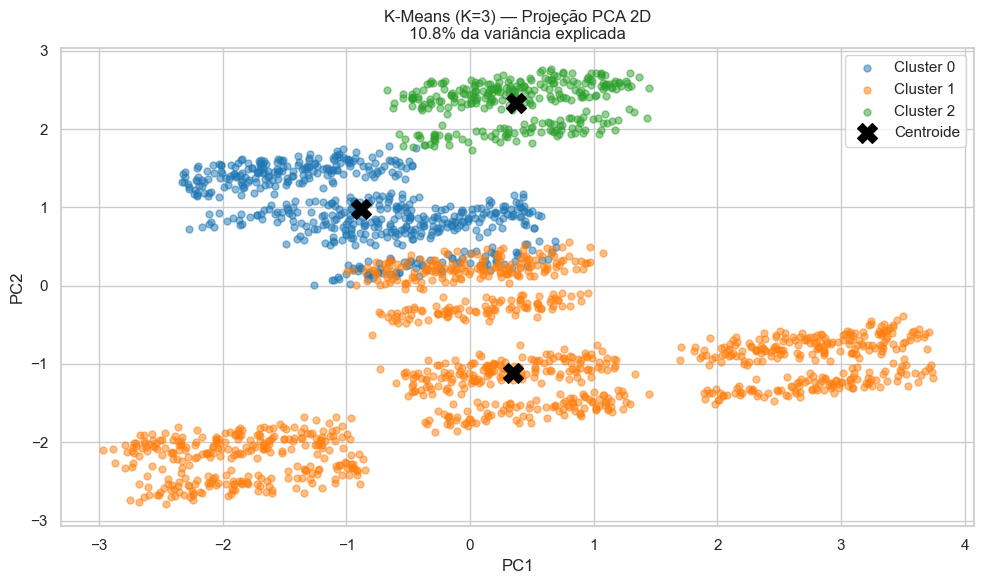

In [5]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

palette = plt.cm.tab10.colors

plt.figure(figsize=(10, 6))
for c in range(K_ESCOLHIDO):
    mask = labels_km == c
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1],
                color=palette[c], label=f'Cluster {c}', alpha=0.5, s=25)

# Centroides no espaço PCA
centroides_pca = pca.transform(kmeans.cluster_centers_)
plt.scatter(centroides_pca[:, 0], centroides_pca[:, 1],
            c='black', marker='X', s=200, zorder=5, label='Centroide')

plt.title(f'K-Means (K={K_ESCOLHIDO}) — Projeção PCA 2D\n'
          f'{pca.explained_variance_ratio_.sum()*100:.1f}% da variância explicada')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend()
plt.tight_layout()
plt.show()

## 4. Perfil de cada cluster
Médias das features originais por cluster — revela o significado de cada grupo.

In [6]:
df_perfil = df_orig.copy()
df_perfil['Cluster'] = labels_km

# Variáveis numéricas
num_cols = ['Age', 'Years_Experience', 'Salary_Before_AI', 'Work_Hours_Per_Week',
            'Job_Satisfaction', 'Productivity_Change_%']

print('=== MÉDIAS NUMÉRICAS POR CLUSTER ===')
display(df_perfil.groupby('Cluster')[num_cols].mean().round(1))

print('\n=== JOB STATUS POR CLUSTER (%) ===')
status_pct = (df_perfil.groupby(['Cluster', 'Job_Status'])
                        .size()
                        .unstack(fill_value=0)
                        .apply(lambda r: r / r.sum() * 100, axis=1)
                        .round(1))
display(status_pct)

=== MÉDIAS NUMÉRICAS POR CLUSTER ===


,Age,Years_Experience,Salary_Before_AI,Work_Hours_Per_Week,Job_Satisfaction,Productivity_Change_%
Cluster,,,,,,
0,40.6,16.8,73824.2,45.0,6.0,9.5
1,40.5,16.6,73763.1,44.9,6.1,10.1
2,40.4,16.6,74847.4,44.6,6.0,9.1



=== JOB STATUS POR CLUSTER (%) ===


Job_Status,Modified,Replaced,Unchanged
Cluster,,,
0,41.9,5.4,52.7
1,37.7,5.2,57.1
2,45.6,5.4,49.0


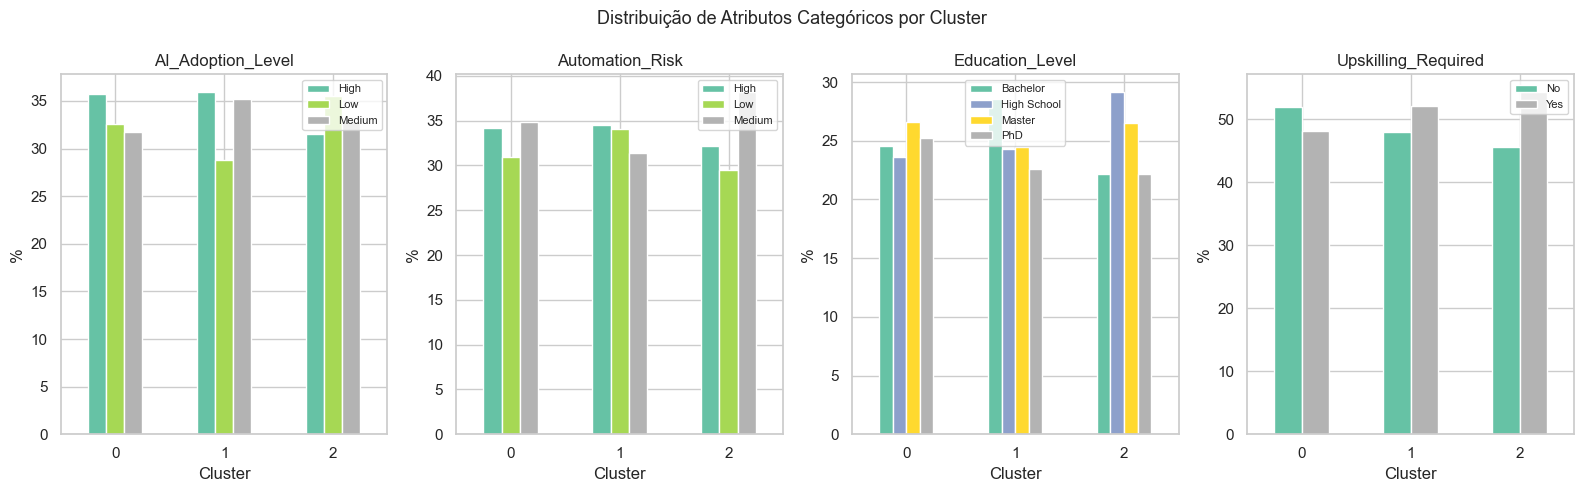

In [7]:
cat_ord = ['AI_Adoption_Level', 'Automation_Risk', 'Education_Level', 'Upskilling_Required']

fig, axes = plt.subplots(1, len(cat_ord), figsize=(16, 5))

for ax, col in zip(axes, cat_ord):
    ct = pd.crosstab(df_perfil['Cluster'], df_perfil[col], normalize='index') * 100
    ct.plot(kind='bar', ax=ax, colormap='Set2', edgecolor='white')
    ax.set_title(col)
    ax.set_xlabel('Cluster')
    ax.set_ylabel('%')
    ax.tick_params(axis='x', rotation=0)
    ax.legend(fontsize=8)

plt.suptitle('Distribuição de Atributos Categóricos por Cluster', fontsize=13)
plt.tight_layout()
plt.show()

## 5. Salvar labels para comparação final

In [8]:
np.save('../dataset/labels_kmeans.npy', labels_km)

import json
metricas_km = {'silhouette': float(sil), 'davies_bouldin': float(dbi), 'k': K_ESCOLHIDO}
with open('../dataset/metricas_kmeans.json', 'w') as f:
    json.dump(metricas_km, f)

print('Labels e métricas salvos.')

Labels e métricas salvos.
